# Session 12 — Evidential Deep Learning: Implementation 🏥

**Part 2 — Core UQ Algorithms**

> *One forward pass. One uncertainty estimate. And a critical look at where the theory meets reality.*

---

### 🎯 What this notebook does

Evidential Deep Learning (EDL) takes a different approach to uncertainty estimation. Instead of sampling multiple models or stochastic forward passes, the network directly learns an evidence distribution for each class from a single deterministic forward pass. This evidence parameterizes a Dirichlet distribution, allowing the model to express both prediction confidence and uncertainty intrinsically.

The notebook walks through the full EDL pipeline step by step:

* **Data loading and preprocessing** — prepare chest X-rays, apply MONAI transforms, and preserve realistic class imbalance through controlled subsampling
* **Building the Evidential DenseNet121** — modify DenseNet121 to output non-negative evidence values instead of conventional logits
* **Training with the evidential loss** — optimize classification performance while regularizing evidence through a KL-based uncertainty penalty
* **Measuring best model performance** — evaluate the saved best model on the held-out test set using accuracy and AUC-ROC
* **Evidential inference on the test set** — convert predicted evidence into Dirichlet parameters, class probabilities, and uncertainty estimates
* **Uncertainty decomposition and visualization** — analyze predictive uncertainty, evidence strength, epistemic uncertainty, and aleatoric uncertainty
* **Clustering test cases into certain vs uncertain subgroups** — separate high-evidence and low-evidence cases using uncertainty metrics
* **Statistical comparison between certain and uncertain cases** — test whether EDL uncertainty meaningfully correlates with predictive reliability
* **Visualization of the most certain and most uncertain chest X-rays** — inspect representative cases with clinical-style interpretation of both the radiograph and the model’s evidential behaviour

---

> **💡 Key difference from Sessions 5–7**  
> - **vs VI:** No BayesLinear, no ELBO. Standard Linear head with ReLU instead of Softmax.
> - **vs MC Dropout:** No T passes at inference — one deterministic forward pass gives uncertainty.
> - **vs Ensembles:** One model, one pass — uncertainty comes from the Dirichlet parameterization, not disagreement.
> - **Unique:** Uncertainty is an analytic property of the output, not a statistical summary of repeated predictions.

<div align="center" style="margin-top: 50px;"> <img src="intro.png" width="700" /> </div>

---
## 📦 Part 1 — Installs and imports

In [1]:
!pip install -q monai torch-uncertainty lightning

import os, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.mixture import GaussianMixture

# MONAI
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, RepeatChanneld,
    ScaleIntensityd, Resized, RandFlipd, RandRotated, EnsureTyped,
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import DenseNet121

# Torch-Uncertainty
from torch_uncertainty.layers.bayesian import BayesLinear
from torch_uncertainty.losses import ELBOLoss
from torch_uncertainty.metrics.classification import CalibrationError, AURC

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 37.2 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-16 20:21:04.399573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778962864.925812      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778962865.037348      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778962866.107460      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778962866.107508      57 computation_placer.cc:1

Device: cuda


---
## 🗂️ Part 2 — Data preparation

Identical to Sessions 5, 6, and 7.

In [2]:
DATA_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

def is_grayscale(path):
    try:
        return Image.open(path).mode in ['L', 'I;16', 'I']
    except:
        return False

def make_split_list_filtered(split_dir):
    normal_files = sorted(glob.glob(os.path.join(split_dir, 'NORMAL', '*')))
    pneu_files   = sorted(glob.glob(os.path.join(split_dir, 'PNEUMONIA', '*')))
    normal_files = [f for f in normal_files if is_grayscale(f)]
    pneu_files   = [f for f in pneu_files   if is_grayscale(f)]
    return ([{'image': f, 'label': 0} for f in normal_files] +
            [{'image': f, 'label': 1} for f in pneu_files])

def subsample_with_ratio(files, n_total, normal_pneu_ratio, seed=42):

    rng    = np.random.default_rng(seed)
    normal = [d for d in files if int(d['label']) == 0]
    pneu   = [d for d in files if int(d['label']) == 1]
    rng.shuffle(normal)
    rng.shuffle(pneu)

    n_pneu   = int(round(n_total / (1 + normal_pneu_ratio)))
    n_normal = n_total - n_pneu

    n_normal = min(n_normal, len(normal))
    n_pneu   = min(n_pneu,   len(pneu))

    subset = normal[:n_normal] + pneu[:n_pneu]
    rng.shuffle(subset)

    actual = n_normal / n_pneu if n_pneu > 0 else float('inf')
    print(f'  NORMAL={n_normal}, PNEUMONIA={n_pneu}, '
          f'total={len(subset)}')
    return subset

train_files_all = make_split_list_filtered(os.path.join(DATA_DIR, 'train'))
val_files_all   = make_split_list_filtered(os.path.join(DATA_DIR, 'val'))
test_files_all  = make_split_list_filtered(os.path.join(DATA_DIR, 'test'))

print('Train subset (normal:pneu = 2.7:1):')
train_files = subsample_with_ratio(train_files_all, n_total=1000,
                                    normal_pneu_ratio=2.7, seed=SEED)
print('Test subset (normal:pneu = 1.7:1):')
test_files  = subsample_with_ratio(test_files_all,  n_total=100,
                                    normal_pneu_ratio=1.7, seed=SEED)
print(f'Val (full): {len(val_files_all)} samples')

Train subset (normal:pneu = 2.7:1):
  NORMAL=730, PNEUMONIA=270, total=1000
Test subset (normal:pneu = 1.7:1):
  NORMAL=63, PNEUMONIA=37, total=100
Val (full): 16 samples


In [3]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    RandRotated(keys=['image'], prob=0.3, range_x=0.12),
    EnsureTyped(keys=['image', 'label']),
])
eval_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    EnsureTyped(keys=['image', 'label']),
])

train_ds = Dataset(data=train_files,   transform=train_tfms)
val_ds   = Dataset(data=val_files_all, transform=eval_tfms)
test_ds  = Dataset(data=test_files,    transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

---
## 🧠 Part 3 — Building the EDL model

The architectural difference from a standard classifier is minimal but critical:
- Final activation: **ReLU** (not Softmax) — outputs must be non-negative evidence values
- Output interpretation: evidence $e_k$ → Dirichlet $\alpha_k = e_k + 1$ → uncertainty $u = K/S$

This is the single structural difference from previous methods. Everything else — backbone, freezing strategy, feature extraction — is identical.

In [ ]:
class EDLDenseNet121(nn.Module):
    """
    MONAI DenseNet121 backbone with an Evidential Deep Learning head.

    The head outputs K evidence values (via ReLU, NOT Softmax).
    Evidence is converted to Dirichlet parameters: alpha_k = e_k + 1.
    Uncertainty is u = K / sum(alpha_k) — high when evidence is low.
    """

    def __init__(self, num_classes=2, freeze_backbone=True):
        super().__init__()
        self.num_classes = num_classes

        backbone = DenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=num_classes,
            pretrained=True,
        )
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))

        # Standard linear head — but NO Softmax
        # Output = evidence values (non-negative via ReLU in forward)
        self.evidence_head = nn.Linear(1024, num_classes)

        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)              # [B, 1024]
        evidence = F.relu(self.evidence_head(x))  # [B, K] — non-negative evidence
        return evidence

    def predict_with_uncertainty(self, x):
        """
        Single forward pass → full uncertainty decomposition.
        No T passes needed. All quantities are analytic.
        """
        evidence = self.forward(x)           # [B, K]
        alpha    = evidence + 1              # Dirichlet params [B, K]
        S        = alpha.sum(dim=1, keepdim=True)  # [B, 1]
        K        = self.num_classes

        probs    = alpha / S                 # mean prediction [B, K]
        u        = K / S.squeeze(1)         # total uncertainty [B]

        # Epistemic: sum of Dirichlet variances
        epistemic = (probs * (1 - probs) / (S + 1)).sum(dim=1)   # [B]

        # Aleatoric: residual after removing epistemic
        aleatoric = (probs * (1 - probs)).sum(dim=1) - epistemic  # [B]

        return probs, u, epistemic, aleatoric, alpha


model = EDLDenseNet121(num_classes=2, freeze_backbone=True).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print()
print('EDL head: nn.Linear(1024, 2) + ReLU')
print('Same number of parameters as a standard classifier.')
print('No extra parameters vs standard. No T passes at inference.')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 138MB/s] 


Total parameters    : 6,955,906
Trainable parameters: 2,050

EDL head: nn.Linear(1024, 2) + ReLU
Same number of parameters as a standard classifier.
No extra parameters vs standard. No T passes at inference.


---
## ⚗️ Part 4 — The EDL loss function

We implement the EDL loss from scratch. The loss combines:
1. **Bayes risk** — penalizes incorrect class predictions under the Dirichlet
2. **KL regularization** — pushes evidence toward zero for wrong classes, with an annealing schedule

The annealing coefficient $\lambda_t = \min(1, t / \text{annealing\_steps})$ starts at 0 and grows to 1. This lets the model fit the data first before the KL regularisation kicks in.

In [5]:
def kl_divergence_dirichlet(alpha, K):
    """
    KL divergence between Dir(alpha) and Dir(1,...,1) (uniform prior).
    Computed analytically using lgamma and digamma.
    """
    beta  = torch.ones_like(alpha)         # uniform prior parameters
    S_a   = alpha.sum(dim=1, keepdim=True)
    S_b   = beta.sum(dim=1, keepdim=True)

    kl = (torch.lgamma(S_a) - torch.lgamma(S_b)
          - torch.lgamma(alpha).sum(dim=1, keepdim=True)
          + torch.lgamma(beta).sum(dim=1, keepdim=True)
          + ((alpha - beta) *
             (torch.digamma(alpha) -
              torch.digamma(S_a))).sum(dim=1, keepdim=True))
    return kl.squeeze(1).mean()


def edl_loss(evidence, labels, epoch, num_epochs, K=2, lambda_max=1.0):
    """
    EDL loss = Bayes risk + annealed KL regularisation.

    Args:
        evidence  : [B, K] — raw evidence output (after ReLU)
        labels    : [B]    — integer class labels
        epoch     : current epoch (for annealing)
        num_epochs: total epochs (for annealing)
        K         : number of classes
        lambda_max: maximum KL weight (reached at end of training)
    """
    alpha    = evidence + 1                     # [B, K]
    S        = alpha.sum(dim=1, keepdim=True)   # [B, 1]
    y_onehot = F.one_hot(labels, num_classes=K).float()  # [B, K]

    # ── Bayes risk (fit term) ─────────────────────────────────────────────────
    # Expected MSE under the Dirichlet
    p_hat = alpha / S                           # [B, K]
    err   = (y_onehot - p_hat) ** 2            # [B, K]
    var   = p_hat * (1 - p_hat) / (S + 1)     # [B, K]
    fit   = (err + var).sum(dim=1).mean()

    # ── KL regularisation (annealed) ──────────────────────────────────────────
    # Remove evidence on correct class before computing KL
    # so we only penalise evidence on wrong classes
    alpha_tilde = y_onehot + (1 - y_onehot) * alpha
    lambda_t    = lambda_max * min(1.0, epoch / (num_epochs * 0.5))
    kl          = kl_divergence_dirichlet(alpha_tilde, K)

    return fit + lambda_t * kl, fit.item(), kl.item(), lambda_t


print('EDL loss implemented:')
print('  Bayes risk (fit term) + λ_t × KL(Dir(α̃) || Dir(1))')
print('  λ_t anneals from 0 to lambda_max over the first 50% of training')

EDL loss implemented:
  Bayes risk (fit term) + λ_t × KL(Dir(α̃) || Dir(1))
  λ_t anneals from 0 to lambda_max over the first 50% of training


## ⚙️ Part 5 — Training

Unlike the previous methods, we do **not** use early stopping based on validation loss for EDL.
The reason is that the EDL objective contains an annealed KL regularization term:

$$
\mathcal{L}
=
\mathcal{L}_{\text{fit}}
+
\lambda_t \mathcal{L}_{\text{KL}}
$$

where the KL weight $\lambda_t$ gradually increases during training.

In early epochs, $\lambda_t$ is close to zero, so the total loss is dominated by the fit term and is naturally smaller. As training progresses, the KL contribution increases intentionally to regularize evidence and improve uncertainty estimation. This means the total validation loss can rise even when the model’s predictive behaviour and uncertainty estimates improve.

Because of this nonstationary loss behaviour, early stopping based on the minimum validation loss would bias training toward under-regularized early epochs and prematurely stop learning before the uncertainty modelling stabilises.

For the same reason, we also avoid learning-rate scheduling based on validation loss. Instead, the model is trained for a fixed number of epochs and the latest checkpoint is saved throughout training.


In [28]:
# Training setup

NUM_EPOCHS = 50
LAMBDA_MAX = 0.5

FINAL_PATH  = "/kaggle/working/final_model.pth"
LATEST_PATH = "/kaggle/working/latest_model.pth"

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print(f'NUM_EPOCHS  : {NUM_EPOCHS}')
print(f'FINAL_PATH  : {FINAL_PATH}')
print(f'LATEST_PATH : {LATEST_PATH}')

NUM_EPOCHS  : 50
FINAL_PATH  : /kaggle/working/final_model.pth
LATEST_PATH : /kaggle/working/latest_model.pth


In [29]:
# History

history = {
    'train_loss': [],
    'fit_loss': [],
    'kl_loss': [],
    'val_loss': [],
    'lambda_t': [],
    'val_acc': [],
    'val_auc': [],
}


# Training loop

for epoch in range(1, NUM_EPOCHS + 1):

    # ─────────────── Train ───────────────
    model.train()

    train_loss = 0.0
    train_fit  = 0.0
    train_kl   = 0.0
    lam_t      = 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):

        images = batch['image'].to(device, dtype=torch.float32)
        labels = batch['label'].to(device, dtype=torch.long)

        optimizer.zero_grad()

        evidence = model(images)

        loss, fit, kl, lam_t = edl_loss(
            evidence,
            labels,
            epoch,
            NUM_EPOCHS,
            K=2,
            lambda_max=LAMBDA_MAX
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_fit  += fit
        train_kl   += kl


    # ─────────────── Validation ───────────────
    model.eval()

    val_loss = 0.0
    val_probs, val_preds, val_labels = [], [], []

    with torch.no_grad():

        for batch in val_loader:

            images = batch['image'].to(device, dtype=torch.float32)
            labels = batch['label'].to(device, dtype=torch.long)

            evidence = model(images)

            loss, _, _, _ = edl_loss(
                evidence,
                labels,
                epoch,
                NUM_EPOCHS,
                K=2,
                lambda_max=LAMBDA_MAX
            )

            val_loss += loss.item()

            probs, _, _, _, _ = model.predict_with_uncertainty(images)

            val_probs.extend(probs[:, 1].cpu().tolist())
            val_preds.extend(probs.argmax(1).cpu().tolist())
            val_labels.extend(labels.cpu().tolist())


    # ─────────────── Metrics ───────────────

    train_loss /= len(train_loader)
    train_fit  /= len(train_loader)
    train_kl   /= len(train_loader)
    val_loss   /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_auc = roc_auc_score(val_labels, val_probs)


    # ─────────────── History ───────────────

    history['train_loss'].append(train_loss)
    history['fit_loss'].append(train_fit)
    history['kl_loss'].append(train_kl)
    history['val_loss'].append(val_loss)
    history['lambda_t'].append(lam_t)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)


    # ─────────────── Logging ───────────────

    print(
    f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
    f'Train Loss: {train_loss:.4f} | '
    f'Val Loss: {val_loss:.4f} | '
    f'Fit: {train_fit:.4f} | '
    f'KL: {train_kl:.4f} | '
    f'λ: {lam_t:.2f} | '
    f'Val Acc: {val_acc:.3f} | '
    f'Val AUC: {val_auc:.3f}' 
    )


    # ─────────────── Save latest model ───────────────

    torch.save(model.state_dict(), LATEST_PATH)
    print(f"📌 Latest model saved at: {LATEST_PATH}")


# Save final model

torch.save(model.state_dict(), FINAL_PATH)

print("\n🏁 Training complete")
print(f"📌 Final model saved at:  {FINAL_PATH}")

Epoch 01/50 | Train Loss: 0.1567 | Val Loss: 0.3481 | Fit: 0.1555 | KL: 0.0611 | λ: 0.02 | Val Acc: 0.812 | Val AUC: 0.875
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 02/50 | Train Loss: 0.1681 | Val Loss: 0.3329 | Fit: 0.1651 | KL: 0.0757 | λ: 0.04 | Val Acc: 0.812 | Val AUC: 0.891
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 03/50 | Train Loss: 0.1519 | Val Loss: 0.3791 | Fit: 0.1480 | KL: 0.0648 | λ: 0.06 | Val Acc: 0.750 | Val AUC: 0.891
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 04/50 | Train Loss: 0.1427 | Val Loss: 0.3718 | Fit: 0.1384 | KL: 0.0537 | λ: 0.08 | Val Acc: 0.750 | Val AUC: 0.906
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 05/50 | Train Loss: 0.1545 | Val Loss: 0.3706 | Fit: 0.1483 | KL: 0.0623 | λ: 0.10 | Val Acc: 0.812 | Val AUC: 0.875
📌 Latest model saved at: /kaggle/working/latest_model.pth


...

Epoch 46/50 | Train Loss: 0.1112 | Val Loss: 0.4181 | Fit: 0.0973 | KL: 0.0277 | λ: 0.50 | Val Acc: 0.812 | Val AUC: 0.922
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 47/50 | Train Loss: 0.1155 | Val Loss: 0.4565 | Fit: 0.1005 | KL: 0.0300 | λ: 0.50 | Val Acc: 0.750 | Val AUC: 0.938
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 48/50 | Train Loss: 0.1073 | Val Loss: 0.4740 | Fit: 0.0932 | KL: 0.0283 | λ: 0.50 | Val Acc: 0.750 | Val AUC: 0.922
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 49/50 | Train Loss: 0.1205 | Val Loss: 0.4480 | Fit: 0.1063 | KL: 0.0284 | λ: 0.50 | Val Acc: 0.688 | Val AUC: 0.922
📌 Latest model saved at: /kaggle/working/latest_model.pth


Epoch 50/50 | Train Loss: 0.1124 | Val Loss: 0.3483 | Fit: 0.0966 | KL: 0.0318 | λ: 0.50 | Val Acc: 0.812 | Val AUC: 0.922
📌 Latest model saved at: /kaggle/working/latest_model.pth

🏁 Training complete
📌 Final model saved at:  /kaggle/working/final_model.pth


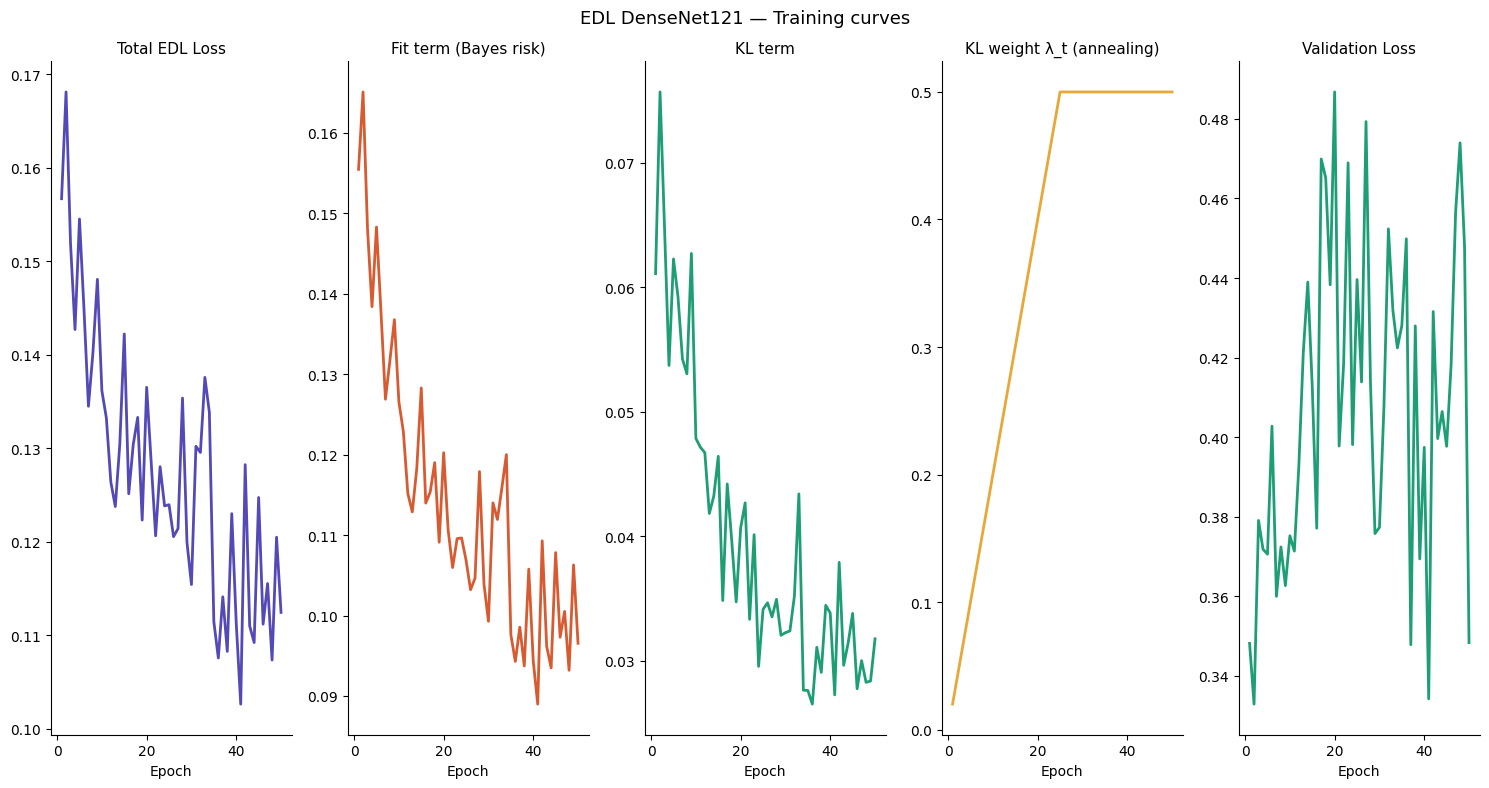

In [30]:
# Training curves — note we track fit and KL separately
fig, axes = plt.subplots(1, 5, figsize=(15, 8))
fig.suptitle('EDL DenseNet121 — Training curves', fontsize=13)
epochs = range(1, len(history['train_loss']) + 1)

for ax, key, color, title in zip(
    axes.flatten(),
    ['train_loss', 'fit_loss', 'kl_loss', 'lambda_t', 'val_loss'],
    ['#534AB7', '#D85A30', '#1D9E75', '#E8A838', '#1D9E75', '#7F77DD'],
    ['Total EDL Loss', 'Fit term (Bayes risk)', 'KL term',
     'KL weight λ_t (annealing)', 'Validation Loss']
):
    ax.plot(epochs, history[key], color=color, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 🔮 Part 6 — Single-pass inference with full decomposition

This is where EDL is structurally different from all other sessions. **One forward pass** gives us:
- Mean prediction (from Dirichlet mean)
- Total uncertainty $u = K/S$
- Epistemic uncertainty (Dirichlet variance)
- Aleatoric uncertainty (residual)

No T passes. No ensemble. No dropout tricks.

In [57]:
# Loading the best model

model = EDLDenseNet121(
    num_classes=2,
    freeze_backbone=True
).to(device)

# I renamed the best model to EDL_best_model.pth and added it to inputs

BEST_PATH = "/kaggle/input/models/benyamingheiji/edl-final-model/pytorch/default/1/edl_final_model.pth"

model.load_state_dict(torch.load(BEST_PATH, map_location=device))

model.eval()

print('✅ Best model loaded successfully')
print(f'Loaded weights from: {BEST_PATH}')

✅ Best model loaded successfully
Loaded weights from: /kaggle/input/models/benyamingheiji/edl-final-model/pytorch/default/1/edl_final_model.pth


In [58]:
def edl_inference(model, loader, device=device):
    """
    EDL inference: ONE deterministic forward pass per image.

    Uncertainty decomposition (Option 2 — Dirichlet Statistics):
        predictive_entropy = entropy of mean prediction         (total)
        aleatoric          = expected entropy under Dirichlet   (data uncertainty)
        epistemic          = predictive_entropy - aleatoric     (model uncertainty, MI)
        vacuity            = K/S                                (EDL-specific, separate)

    predictive_entropy = epistemic + aleatoric  ✅
    """
    model.eval()

    all_mean_preds, all_vacuity, all_epistemic, all_aleatoric, all_predictive = [], [], [], [], []
    all_evidence_sum, all_labels, all_paths, all_images = [], [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='EDL inference (single pass)'):
            images = batch['image'].to(device, dtype=torch.float32)
            labels = batch['label'].cpu().numpy()
            paths  = (batch.get('image_meta_dict', {}).get('filename_or_obj')
                      or [''] * len(labels))

            probs, u, epistemic, aleatoric, alpha = \
                model.predict_with_uncertainty(images)

            S                  = alpha.sum(dim=1)
            predictive_entropy = epistemic + aleatoric   # [B] additive ✅

            all_mean_preds.extend(probs[:, 1].cpu().tolist())
            all_vacuity.extend(u.cpu().tolist())
            all_predictive.extend(predictive_entropy.cpu().tolist())
            all_epistemic.extend(epistemic.cpu().tolist())
            all_aleatoric.extend(aleatoric.cpu().tolist())
            all_evidence_sum.extend(S.cpu().tolist())
            all_labels.extend(labels.tolist())
            all_paths.extend(list(paths))
            all_images.extend(images.cpu().unbind(0))

    preds   = (np.array(all_mean_preds) >= 0.5).astype(int)
    correct = (preds == np.array(all_labels)).astype(int)

    results = pd.DataFrame({
        'image_path'         : all_paths,
        'true_label'         : all_labels,
        'mean_pred'          : all_mean_preds,
        'pred_label'         : preds.tolist(),
        'vacuity'            : all_vacuity,      # K/S — EDL-specific
        'predictive_entropy' : all_predictive,   # epistemic + aleatoric ✅
        'epistemic_mi'       : all_epistemic,
        'aleatoric_h'        : all_aleatoric,
        'evidence_strength'  : all_evidence_sum,
        'correct'            : correct.tolist(),
    })
    return results, all_images


# ── Inference ──────────────────────────────────────────────────────────────────

results, test_images = edl_inference(model, test_loader, device=device)

print(f'Test samples  : {len(results)}')
print(f'Accuracy      : {results["correct"].mean():.3f}')
print(f'AUC-ROC       : {roc_auc_score(results["true_label"], results["mean_pred"]):.3f}')

EDL inference (single pass): 100%|██████████| 4/4 [00:06<00:00,  1.58s/it]

Test samples  : 100
Accuracy      : 0.910
AUC-ROC       : 0.961


## 🎲 Part 7 — Uncertainty decomposition across the test set

We now analyze how the EDL model decomposes predictive uncertainty on unseen chest X-rays into total, epistemic, and aleatoric components. The following plots show the distribution of uncertainty across the test set, the contribution of each uncertainty type per case, and the relationship between prediction confidence and uncertainty

In [59]:
print('\nUncertainty decomposition (mean across test set):')
print(f'  Predictive entropy : {results["predictive_entropy"].mean():.6f}')
print(f'  Epistemic (MI)     : {results["epistemic_mi"].mean():.6f}')
print(f'  Aleatoric (H)      : {results["aleatoric_h"].mean():.6f}')
print(f'  Vacuity (K/S)      : {results["vacuity"].mean():.4f}')
print(f'  Mean evidence S    : {results["evidence_strength"].mean():.4f}')


Uncertainty decomposition (mean across test set):
  Predictive entropy : 0.235065
  Epistemic (MI)     : 0.030251
  Aleatoric (H)      : 0.204815
  Vacuity (K/S)      : 0.2670
  Mean evidence S    : 8.4491


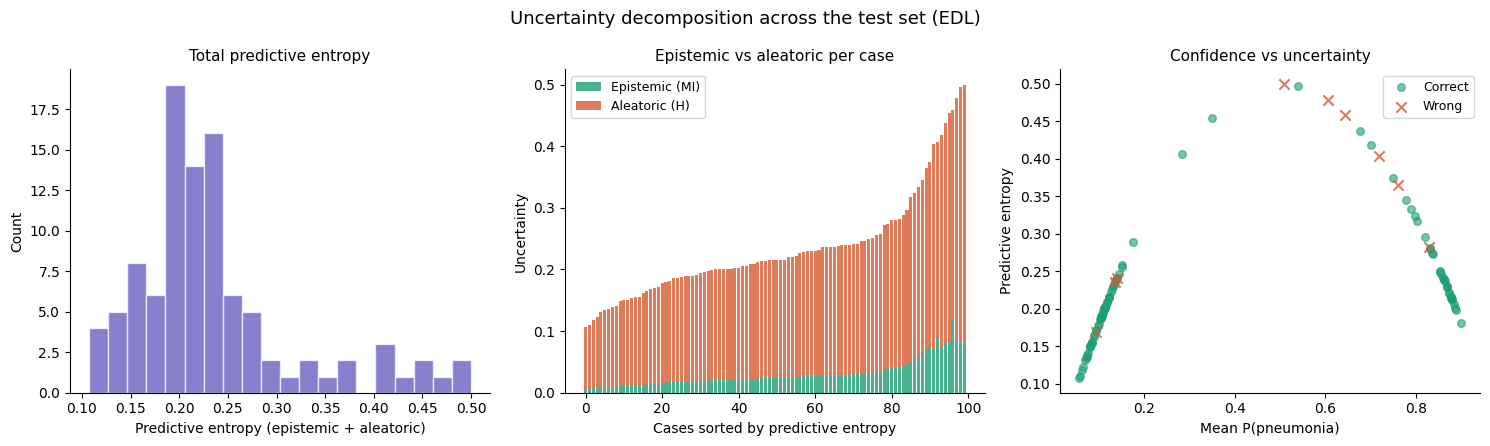

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Uncertainty decomposition across the test set (EDL)', fontsize=13)

axes[0].hist(results['predictive_entropy'], bins=20,
             color='#534AB7', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Predictive entropy (epistemic + aleatoric)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Total predictive entropy', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

idx_sorted = results['predictive_entropy'].argsort().values
axes[1].bar(range(len(results)),
            results['epistemic_mi'].values[idx_sorted],
            color='#1D9E75', alpha=0.8, label='Epistemic (MI)')
axes[1].bar(range(len(results)),
            results['aleatoric_h'].values[idx_sorted],
            bottom=results['epistemic_mi'].values[idx_sorted],
            color='#D85A30', alpha=0.8, label='Aleatoric (H)')
axes[1].set_xlabel('Cases sorted by predictive entropy', fontsize=10)
axes[1].set_ylabel('Uncertainty', fontsize=10)
axes[1].set_title('Epistemic vs aleatoric per case', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

correct_mask = results['correct'].astype(bool)
axes[2].scatter(results.loc[correct_mask,  'mean_pred'],
                results.loc[correct_mask,  'predictive_entropy'],
                c='#1D9E75', alpha=0.6, s=30, label='Correct')
axes[2].scatter(results.loc[~correct_mask, 'mean_pred'],
                results.loc[~correct_mask, 'predictive_entropy'],
                c='#D85A30', alpha=0.8, s=55, marker='x', label='Wrong')
axes[2].set_xlabel('Mean P(pneumonia)', fontsize=10)
axes[2].set_ylabel('Predictive entropy', fontsize=10)
axes[2].set_title('Confidence vs uncertainty', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The figure illustrates the uncertainty decomposition obtained from the **EDL** framework on the test set. The left panel shows the distribution of total predictive uncertainty, measured using entropy, across all test samples. The middle panel decomposes uncertainty into **epistemic** and **aleatoric** components for each case, sorted by increasing predictive entropy. Similar to many medical imaging applications, aleatoric uncertainty dominates most predictions, while epistemic uncertainty remains comparatively small and increases slightly for the most uncertain cases. The right panel relates the predicted probability of the positive class to predictive entropy, showing that uncertainty is highest near the decision boundary and lower for highly confident predictions. Misclassified cases tend to occur in regions of elevated uncertainty, indicating that the model appropriately expresses lower confidence for more challenging samples.

---
## 📊 Part 8 — Clustering certain vs uncertain cases

We split the test set into **certain** and **uncertain** groups using the median entropy as the threshold, then:

1. Compare accuracy and AUC between groups
2. Run a **Mann-Whitney U test** (non-parametric, no normality assumption) to check whether the uncertainty scores of correct and wrong predictions are statistically distinguishable

If EDL produces meaningful uncertainty, the uncertain group should have lower accuracy — the model should be less reliable precisely when it says it's unsure.

In [61]:
# Run stochastic inference on validation set
# We use validation entropy distribution to LEARN the uncertainty threshold.
# Then we apply that threshold to the TEST set.

val_results, _ = edl_inference(
    model,
    val_loader,
    device=device
)

# Fit GMM on VALIDATION entropy

X_val = val_results['predictive_entropy'].values.reshape(-1, 1)

gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm.fit(X_val)

# Find threshold between the two Gaussians

means = gmm.means_.flatten()
means = np.sort(means)

# midpoint between Gaussian means
threshold = means.mean()

print('GMM learned from VALIDATION set')
print(f'Cluster means         : {means}')
print(f'Entropy threshold     : {threshold:.4f}')

EDL inference (single pass): 100%|██████████| 1/1 [00:01<00:00,  1.33s/it]

GMM learned from VALIDATION set
Cluster means         : [0.25514051 0.39717278]
Entropy threshold     : 0.3262



Certain group   : 87 cases
Uncertain group : 13 cases

📊 Certain vs Uncertain Summary


,Group,N Cases,Accuracy,AUC-ROC,Mean Pred Entropy,Mean Epistemic,Mean Aleatoric,Mean Vacuity
0,Certain,87,0.9540,0.9677,0.2073,0.0230,0.1843,0.2373
1,Uncertain,13,0.6154,0.7857,0.4210,0.0791,0.3419,0.4659



📊 Mann-Whitney U test
H0: entropy(correct) == entropy(wrong)
U statistic : 151.00
p-value     : 0.0009

📊 Z-test for accuracy difference
H0: accuracy(certain) == accuracy(uncertain)
Z statistic : 3.979
p-value     : 0.0001


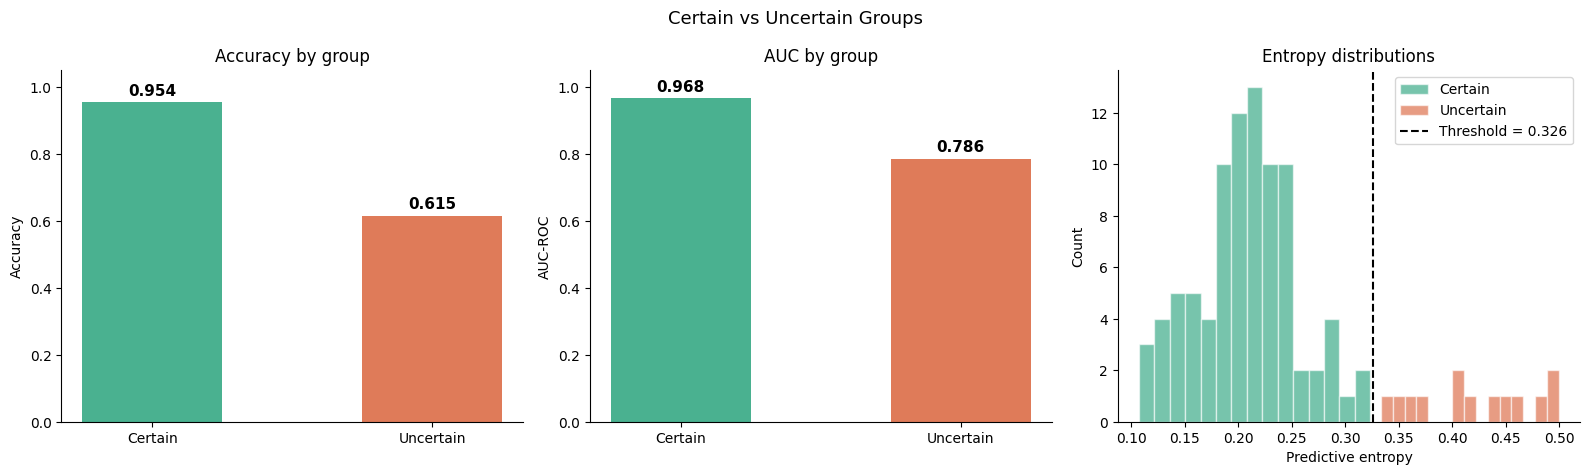

In [62]:
# ── Apply threshold to TEST set ───────────────────────────────────────────────

results['uncertainty_group'] = np.where(
    results['predictive_entropy'] > threshold,
    'Uncertain',
    'Certain'
)

certain   = results[results['uncertainty_group'] == 'Certain']
uncertain = results[results['uncertainty_group'] == 'Uncertain']

print(f'\nCertain group   : {len(certain)} cases')
print(f'Uncertain group : {len(uncertain)} cases')


# ── Metrics function ───────────────────────────────────────────────────────────

def group_metrics(df, name):
    acc      = df['correct'].mean()
    auc      = (roc_auc_score(df['true_label'], df['mean_pred'])
                if df['true_label'].nunique() > 1 else float('nan'))
    mean_ent = df['predictive_entropy'].mean()
    mean_epi = df['epistemic_mi'].mean()
    mean_ale = df['aleatoric_h'].mean()
    mean_vac = df['vacuity'].mean()

    return {
        'Group'             : name,
        'N Cases'           : len(df),
        'Accuracy'          : acc,
        'AUC-ROC'           : auc,
        'Mean Pred Entropy' : mean_ent,
        'Mean Epistemic'    : mean_epi,
        'Mean Aleatoric'    : mean_ale,
        'Mean Vacuity'      : mean_vac,
    }


# ── Summary table ─────────────────────────────────────────────────────────────

certain_metrics   = group_metrics(certain,   'Certain')
uncertain_metrics = group_metrics(uncertain, 'Uncertain')

summary_df = pd.DataFrame([certain_metrics, uncertain_metrics])

summary_display = summary_df.copy()
for col in ['Accuracy', 'AUC-ROC', 'Mean Pred Entropy',
            'Mean Epistemic', 'Mean Aleatoric', 'Mean Vacuity']:
    summary_display[col] = summary_display[col].map(lambda x: f'{x:.4f}')

print('\n📊 Certain vs Uncertain Summary')
display(summary_display)

acc_cert   = certain_metrics['Accuracy']
acc_uncert = uncertain_metrics['Accuracy']
auc_cert   = certain_metrics['AUC-ROC']
auc_uncert = uncertain_metrics['AUC-ROC']


# ── Statistical tests ─────────────────────────────────────────────────────────

entropy_correct = results.loc[results['correct'] == 1, 'predictive_entropy'].values
entropy_wrong   = results.loc[results['correct'] == 0, 'predictive_entropy'].values

if len(entropy_wrong) > 0 and len(entropy_correct) > 0:
    stat, p_value = stats.mannwhitneyu(entropy_correct, entropy_wrong, alternative='less')
    print('\n📊 Mann-Whitney U test')
    print('H0: entropy(correct) == entropy(wrong)')
    print(f'U statistic : {stat:.2f}')
    print(f'p-value     : {p_value:.4f}')

stat2, p2 = proportions_ztest(
    [int(acc_cert * len(certain)), int(acc_uncert * len(uncertain))],
    [len(certain), len(uncertain)]
)
print('\n📊 Z-test for accuracy difference')
print('H0: accuracy(certain) == accuracy(uncertain)')
print(f'Z statistic : {stat2:.3f}')
print(f'p-value     : {p2:.4f}')


# ── Certain vs Uncertain plots ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('Certain vs Uncertain Groups', fontsize=13)

groups = ['Certain', 'Uncertain']
colors = ['#1D9E75', '#D85A30']

axes[0].bar(groups, [acc_cert, acc_uncert], color=colors, alpha=0.8, width=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by group')
for i, v in enumerate([acc_cert, acc_uncert]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].bar(groups, [auc_cert, auc_uncert], color=colors, alpha=0.8, width=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC by group')
for i, v in enumerate([auc_cert, auc_uncert]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

axes[2].hist(certain['predictive_entropy'],   bins=15, alpha=0.6,
             color='#1D9E75', edgecolor='white', label='Certain')
axes[2].hist(uncertain['predictive_entropy'], bins=15, alpha=0.6,
             color='#D85A30', edgecolor='white', label='Uncertain')
axes[2].axvline(threshold, color='black', linestyle='--',
                linewidth=1.5, label=f'Threshold = {threshold:.3f}')
axes[2].set_xlabel('Predictive entropy')
axes[2].set_ylabel('Count')
axes[2].set_title('Entropy distributions')
axes[2].legend()
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The figure compares model performance between test samples classified as **certain** and **uncertain** based on a predictive entropy threshold of **0.326** derived from the EDL uncertainty estimates. The left panel shows that the model achieves substantially higher accuracy on the certain group (**95.4%**) than on the uncertain group (**61.5%**). The middle panel demonstrates a similar trend for discrimination performance, with AUC-ROC decreasing from **0.968** in the certain group to **0.786** in the uncertain group. The right panel visualizes the entropy distributions for both groups, showing a clear separation between low-entropy (certain) and high-entropy (uncertain) samples around the chosen threshold. These results indicate that predictive entropy effectively identifies more challenging cases, with uncertain samples exhibiting markedly lower predictive performance and reliability.

---
## 🏥 Part 9 — Medical visualization

We present two most certain and two most uncertain cases from the test set

In [63]:
# Visualisation helper
LABEL_NAMES = {0: 'Normal', 1: 'Pneumonia'}

def tensor_to_display(x):
    img = x[0].numpy()
    img = np.rot90(img, k=-1)
    img = np.fliplr(img)
    return np.clip(img, 0, 1)

def plot_xray_group(indices, results_df, images_list, group_title, n_show=2):
    indices = list(indices)[:n_show]
    if not indices:
        print(f'No cases to show for: {group_title}')
        return

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5.5))
    if len(indices) == 1:
        axes = [axes]

    fig.suptitle(group_title, fontsize=13, fontweight='bold', y=1.02)

    for ax, idx in zip(axes, indices):
        row       = results_df.loc[idx]
        img       = tensor_to_display(images_list[idx])
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        true_name = LABEL_NAMES[int(row['true_label'])]
        pred_name = LABEL_NAMES[int(row['pred_label'])]
        verdict   = '✓ Correct' if row['correct'] else '✗ Wrong'
        color     = '#1D9E75'   if row['correct'] else '#D85A30'

        title = (
            f'{verdict}\n'
            f'True: {true_name}\n'
            f'Pred: {pred_name} ({row["mean_pred"]:.2f})\n'
            f'Entropy: {row["predictive_entropy"]:.4f}\n'
            f'Epistemic: {row["epistemic_mi"]:.5f}\n'
            f'Aleatoric: {row["aleatoric_h"]:.5f}'
        )
        ax.set_title(title, fontsize=9, color=color, pad=5)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_57/2905618606.py:43: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


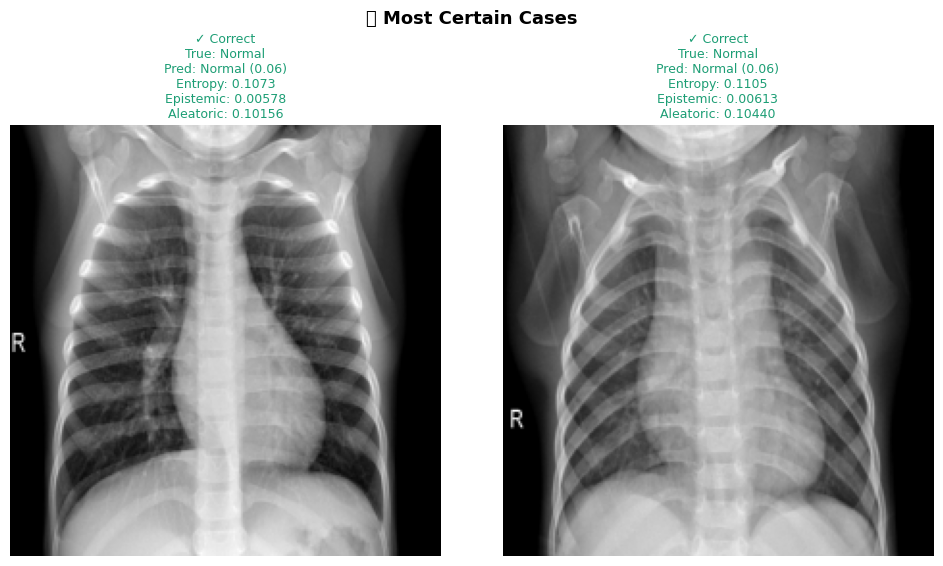

In [64]:
# MOST CERTAIN CASES

most_certain_idx = (
    certain
    .nsmallest(2, 'predictive_entropy')
    .index.tolist()
)

plot_xray_group(
    most_certain_idx,
    results,
    test_images,
    '🟢 Most Certain Cases'
)

/tmp/ipykernel_57/2905618606.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


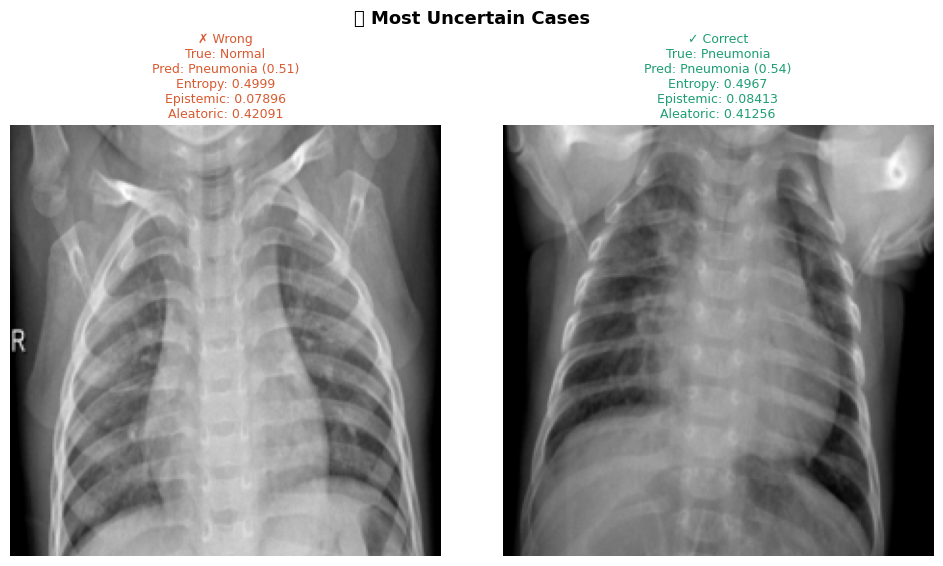

In [65]:
# MOST UNCERTAIN CASES

most_uncertain_idx = (
    uncertain
    .nlargest(2, 'predictive_entropy')
    .index.tolist()
)

plot_xray_group(
    most_uncertain_idx,
    results,
    test_images,
    '🔴 Most Uncertain Cases'
)

---
## 💾 Part 10 — Save results

In [66]:
results['method'] = 'EDL'

save_path = '/kaggle/working/results_edl.csv'
results.to_csv(save_path, index=False)

print(f'Results saved to: {save_path}')

Results saved to: /kaggle/working/results_edl.csv


---
## ✅ Session summary

| Step | What we did |
|---|---|
| 🗂️ Data | Subsampled with class ratios (normal:pneu = 2.7:1 train, 1.7:1 test) |
| 🧠 Model | MONAI DenseNet121 + `nn.Linear` with ReLU (not Softmax) — evidence head |
| ⚗️ Loss | Bayes risk + KL annealing (λ_t 0→λ_max over training) |
| 🔮 Inference | One forward pass — u, epistemic, aleatoric all analytic from Dirichlet |
| 🧩 Decomposition | Total = Epistemic (MI) + Aleatoric (expected H) — per image |
| 📊 Statistics | Mann-Whitney U test on entropy and accuracy of correct vs wrong predictions |
| 🏥 Visualization | Most Certain and Most Uncertain cases|

---

> **➡️ Next: Session 13 — Conformal Prediction**  
> Session 13 introduces Conformal Prediction: a shift from estimating uncertainty to building prediction sets with finite-sample coverage guarantees. After VI, MC Dropout, Deep Ensembles, and EDL, the next question is different: can we wrap any trained model with a procedure that says, with a chosen confidence level, whether the true label should be inside the returned set?
